# LSTM Notebook

This notebook provides an example of working with the LSTM model. It
shows the process of loading per-game data for premier league forwards for
the current season, splitting into train/test sets, creating datasets and
dataloaders from them, training a `FootballLSTM` instance, and evaluating
it.

In [1]:
import sys
import os
import pandas as pd
from understatapi import UnderstatClient
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from matplotlib import pyplot as plt
import numpy as np

# Also import local helpers
target_dir = os.path.abspath('..') 

if target_dir not in sys.path:
    sys.path.append(target_dir)
    
from preprocess import get_position_players_stats_df, CustomFootballDataset, merge_stats_df_with_transfermarkt
from football_lstm import FootballLSTM
from utils import hyperparam_tuning

In [2]:
# have GPU available to speed up
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cpu


In [3]:
# Create understat connection
understat = UnderstatClient()

In [45]:
# Choose what stats to forecast, and how many past games to use to predict
# the current one
stats = ["goals", "xG", "assists", "xA", "key_passes", "xGChain", "xGBuildup"]
per_90_stats = list(map(lambda s: f"{s}_per_90", stats))
games_per_block = 10

In [5]:
### ONLY UNCOMMENT IF NEED TO PULL NEW POSITION DATA ###
### MAKE SURE THAT YOU CHANGE DF NAME ###

# Get forward stats for all seasons in top 5 leagues
# leagues = ["EPL", "La_Liga", "Bundesliga", "Serie_A", "Ligue_1"]
# seasons = list(range(2014,2026))
positions = ['F'] # forwards saved to csv, no need to run again
# 
# f_stats = get_position_players_stats_df(understat, positions, games_per_block, stats, leagues=leagues, seasons=seasons)
#f_stats.head()
# 
# # save dataset to csv to avoid pulls from understat every time as it can take 5-10min for just one position
# os.makedirs("data", exist_ok=True)  
# 
# # to be able to save datasets for a set of positions
# f_stats.to_csv(f"../data/{'_'.join(positions)}_stats.csv", index=True)

In [42]:
# Read in saved df
f_stats_df = pd.read_csv(f"../data/{'_'.join(positions)}_stats_2.csv")

# Convert date to appropriate type
f_stats_df['date'] = pd.to_datetime(f_stats_df['date'])

f_stats_df = f_stats_df.set_index(['player_id', 'player_name', 'date', 'league'])

f_stats_df.head()

### MAKE SURE THAT YOU CHANGE DF NAME IF NEW CSV ###
### AND THAT ALL DF BELOW ARE UPDATED TO MATCH NEW DF NAME ###

goals_per_90  \
player_id player_name      date                league                     
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga      0.207852   
                           2016-03-05 18:30:00 Bundesliga      0.111940   
                           2021-08-14 13:30:00 Bundesliga      0.000000   
                           2021-12-17 19:30:00 Bundesliga      0.000000   
                           2022-04-03 13:30:00 Bundesliga      0.000000   

                                                           xG_per_90  \
player_id player_name      date                league                  
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga   0.076191   
                           2016-03-05 18:30:00 Bundesliga   0.147187   
                           2021-08-14 13:30:00 Bundesliga   0.004439   
                           2021-12-17 19:30:00 Bundesliga   0.038612   
                           2022-04-03 13:30:00 Bundesliga   0.143876   

                                                           assists_per_90  \
player_id player_name      date                league                       
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga        0.000000   
                           2016-03-05 18:30:00 Bundesliga        0.111940   
                           2021-08-14 13:30:00 Bundesliga        0.412214   
                           2021-12-17 19:30:00 Bundesliga        0.000000   
                           2022-04-03 13:30:00 Bundesliga        0.000000   

                                                           xA_per_90  \
player_id player_name      date                league                  
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga   0.152804   
                           2016-03-05 18:30:00 Bundesliga   0.097708   
                           2021-08-14 13:30:00 Bundesliga   0.149183   
                           2021-12-17 19:30:00 Bundesliga   0.122557   
                           2022-04-03 13:30:00 Bundesliga   0.016857   

                                                           key_passes_per_90  \
player_id player_name      date                league                          
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga           1.454965   
                           2016-03-05 18:30:00 Bundesliga           1.119403   
                           2021-08-14 13:30:00 Bundesliga           0.961832   
                           2021-12-17 19:30:00 Bundesliga           0.432000   
                           2022-04-03 13:30:00 Bundesliga           0.623557   

                                                           xGChain_per_90  \
player_id player_name      date                league                       
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga        0.276498   
                           2016-03-05 18:30:00 Bundesliga        0.419527   
                           2021-08-14 13:30:00 Bundesliga        0.423672   
                           2021-12-17 19:30:00 Bundesliga        0.267215   
                           2022-04-03 13:30:00 Bundesliga        0.317156   

                                                           xGBuildup_per_90  
player_id player_name      date                league                        
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga          0.165737  
                           2016-03-05 18:30:00 Bundesliga          0.204866  
                           2021-08-14 13:30:00 Bundesliga          0.274489  
                           2021-12-17 19:30:00 Bundesliga          0.123039  
                           2022-04-03 13:30:00 Bundesliga          0.181113

In [7]:
# Train/test split by player
all_players = f_stats_df.index.get_level_values('player_id').unique()

# 80/20 split
np.random.seed(42)
train_players = np.random.choice(all_players, size=int(0.8*len(all_players)), replace=False)

train_df = f_stats_df[f_stats_df.index.get_level_values('player_id').isin(train_players)]
test_df = f_stats_df[~f_stats_df.index.get_level_values('player_id').isin(train_players)]

In [8]:
train_df.head()

goals_per_90  \
player_id player_name      date                league                     
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga      0.207852   
                           2016-03-05 18:30:00 Bundesliga      0.111940   
                           2021-08-14 13:30:00 Bundesliga      0.000000   
                           2021-12-17 19:30:00 Bundesliga      0.000000   
                           2022-04-03 13:30:00 Bundesliga      0.000000   

                                                           xG_per_90  \
player_id player_name      date                league                  
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga   0.076191   
                           2016-03-05 18:30:00 Bundesliga   0.147187   
                           2021-08-14 13:30:00 Bundesliga   0.004439   
                           2021-12-17 19:30:00 Bundesliga   0.038612   
                           2022-04-03 13:30:00 Bundesliga   0.143876   

                                                           assists_per_90  \
player_id player_name      date                league                       
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga        0.000000   
                           2016-03-05 18:30:00 Bundesliga        0.111940   
                           2021-08-14 13:30:00 Bundesliga        0.412214   
                           2021-12-17 19:30:00 Bundesliga        0.000000   
                           2022-04-03 13:30:00 Bundesliga        0.000000   

                                                           xA_per_90  \
player_id player_name      date                league                  
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga   0.152804   
                           2016-03-05 18:30:00 Bundesliga   0.097708   
                           2021-08-14 13:30:00 Bundesliga   0.149183   
                           2021-12-17 19:30:00 Bundesliga   0.122557   
                           2022-04-03 13:30:00 Bundesliga   0.016857   

                                                           key_passes_per_90  \
player_id player_name      date                league                          
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga           1.454965   
                           2016-03-05 18:30:00 Bundesliga           1.119403   
                           2021-08-14 13:30:00 Bundesliga           0.961832   
                           2021-12-17 19:30:00 Bundesliga           0.432000   
                           2022-04-03 13:30:00 Bundesliga           0.623557   

                                                           xGChain_per_90  \
player_id player_name      date                league                       
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga        0.276498   
                           2016-03-05 18:30:00 Bundesliga        0.419527   
                           2021-08-14 13:30:00 Bundesliga        0.423672   
                           2021-12-17 19:30:00 Bundesliga        0.267215   
                           2022-04-03 13:30:00 Bundesliga        0.317156   

                                                           xGBuildup_per_90  
player_id player_name      date                league                        
140       Yannick Gerhardt 2015-11-21 18:30:00 Bundesliga          0.165737  
                           2016-03-05 18:30:00 Bundesliga          0.204866  
                           2021-08-14 13:30:00 Bundesliga          0.274489  
                           2021-12-17 19:30:00 Bundesliga          0.123039  
                           2022-04-03 13:30:00 Bundesliga          0.181113

In [9]:
# Create datasets
blocks_per_input = 5

train_dataset = CustomFootballDataset(train_df, blocks_per_input, multiple_players=True)
test_dataset = CustomFootballDataset(test_df, blocks_per_input, multiple_players=True)

In [10]:
len(train_dataset)

7108

In [11]:
# Create dataloaders

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [12]:
# Tuning params
params = {
    "learning_rates": [0.01, 0.001],      
    "epochs": [20],        
    "layers": [1, 2],                            
    "h_sizes": [32, 64, 128, 256],                  
    "dropouts": [0.3]                
}

opt_hyper_params = hyperparam_tuning(params, stats_df=f_stats_df, train_dataloader=train_dataloader, 
                                             test_dataloader=test_dataloader)

print(f"""
      Best Hyperparameter setup \n
      - learning rate: {opt_hyper_params['learning_rate']} 
      - number of epochs: {opt_hyper_params['epoch']}.
      - number of layers: {opt_hyper_params['layers']}.
      - hidden size: {opt_hyper_params['hidden_size']}.
      - dropout: {opt_hyper_params['dropout']}.
      """)

learning_rates:   0%|          | 0/2 [00:00<?, ?it/s]

epochs:   0%|          | 0/1 [00:00<?, ?it/s]

layers:   0%|          | 0/2 [00:00<?, ?it/s]

h_sizes:   0%|          | 0/4 [00:00<?, ?it/s]

dropouts:   0%|          | 0/1 [00:00<?, ?it/s]

...

dropouts:   0%|          | 0/1 [00:00<?, ?it/s]

dropouts:   0%|          | 0/1 [00:00<?, ?it/s]

dropouts:   0%|          | 0/1 [00:00<?, ?it/s]

dropouts:   0%|          | 0/1 [00:00<?, ?it/s]


      Best Hyperparameter setup 

      - learning rate: 0.001 
      - number of epochs: 20.
      - number of layers: 1.
      - hidden size: 64.
      - dropout: 0.
      


In [ ]:
# Tuned setup to MSE Loss and Adam
loss_fn = nn.MSELoss()
model = FootballLSTM(n_features=len(f_stats_df.columns), hidden_size=opt_hyper_params['hidden_size'], 
                     num_layers=opt_hyper_params['layers'], dropout=opt_hyper_params['dropout']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=opt_hyper_params['learning_rate'])
num_epochs = opt_hyper_params['epoch']

# Train model
train_losses, test_losses = model.train_model(
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    n_epochs=num_epochs,
    test_every=float('inf')
)

In [34]:
# Evaluate test performance

rmse, mae = model.eval_model(test_dataloader)
print(f"Test RMSE: {rmse}")
print(f"Test MAE: {mae}")

Test RMSE: 0.2300676852464676
Test MAE: 0.17384472489356995


RMSE: 0.2215394228696823
MAE: 0.18071503937244415
goals_per_90 RMSE: 0.3211718797683716
goals_per_90 MAE: 0.25013303756713867
xG_per_90 RMSE: 0.17923584580421448
xG_per_90 MAE: 0.15348969399929047
assists_per_90 RMSE: 0.14652183651924133
assists_per_90 MAE: 0.1176118552684784
xA_per_90 RMSE: 0.07320554554462433
xA_per_90 MAE: 0.06365752220153809
key_passes_per_90 RMSE: 0.4672882556915283
key_passes_per_90 MAE: 0.36067554354667664
xGChain_per_90 RMSE: 0.26141440868377686
xGChain_per_90 MAE: 0.23014110326766968
xGBuildup_per_90 RMSE: 0.10193835943937302
xGBuildup_per_90 MAE: 0.08929645270109177


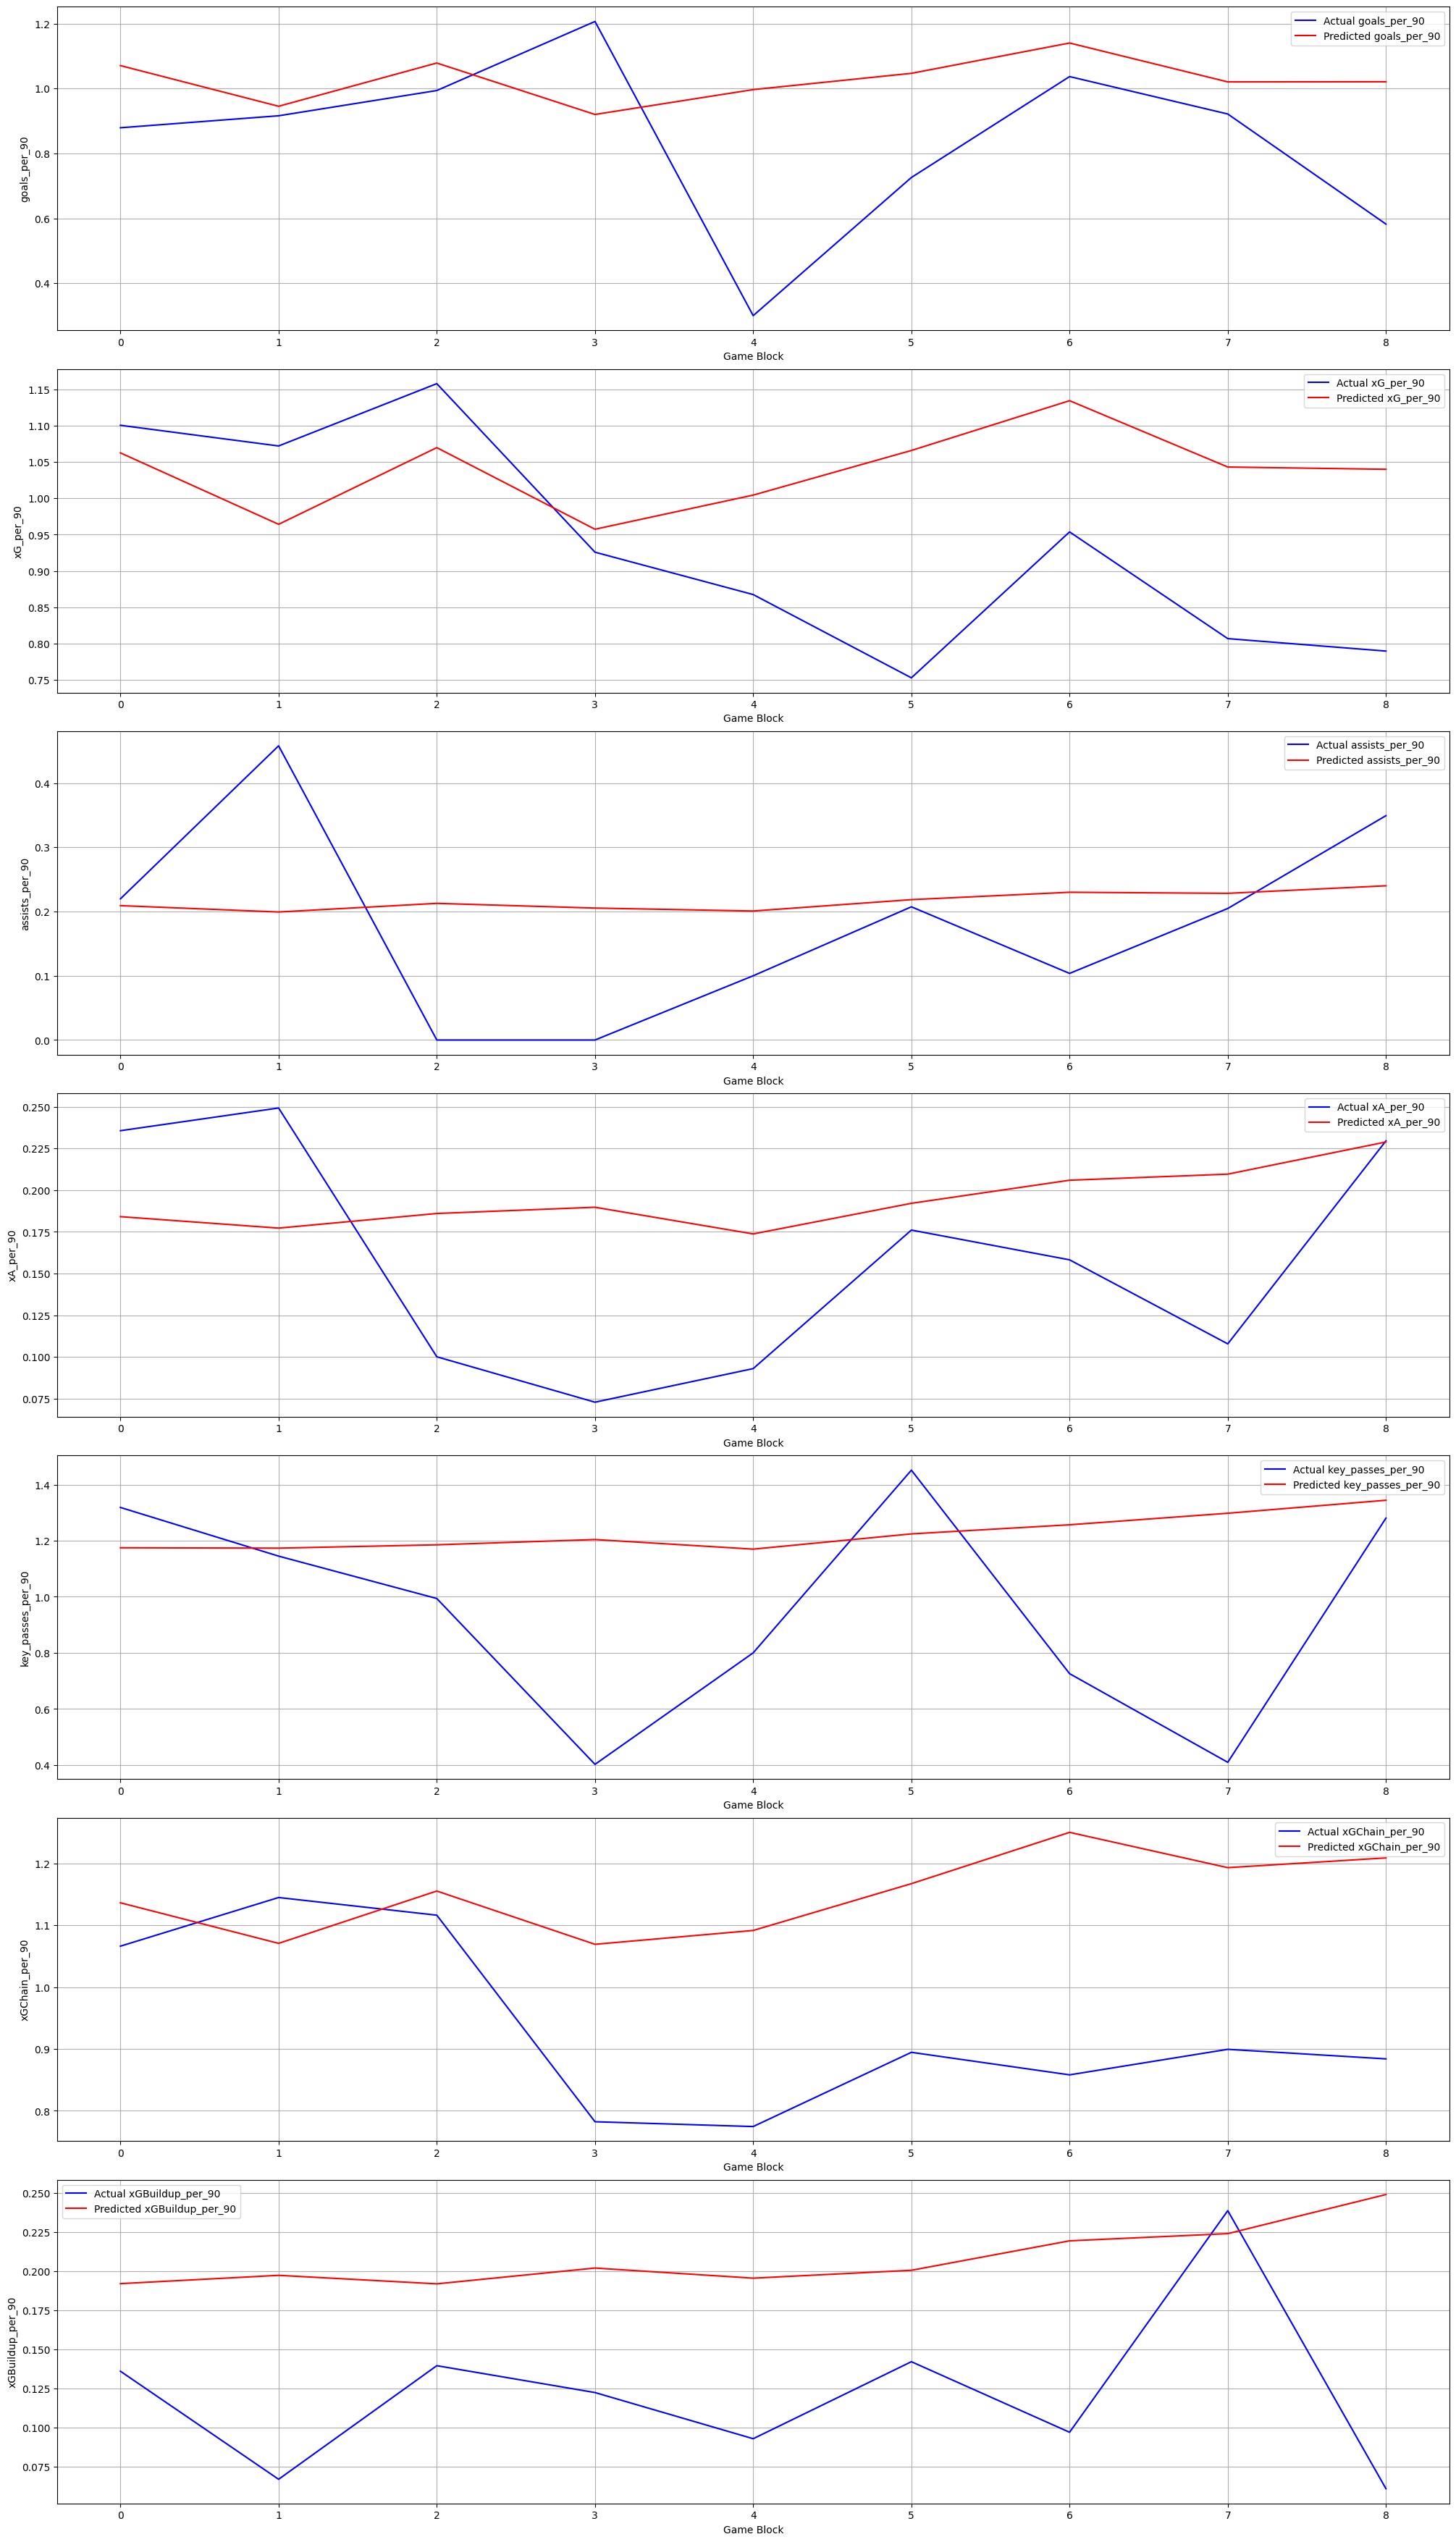

In [35]:
# See how model does on forecasting a specific player--Erling Haaland

haaland_df = f_stats_df.loc[8260]

model.eval_model_on_player(haaland_df)

In [36]:
# Get predictions and actuals for each test player and save to csv

# For each test player, get most first blocks_per_input games, then predict the rest
# with LSTM. Also get approx. future dates, and use whatever league they last
# played in.

ids = []
names = []
dates = []
leagues = []
preds = []

def get_k_future_dates(player_df, k):
    # Get the dates of existing blocks
    block_dates = player_df.index.get_level_values('date')
    
    # Calculate average time between consecutive blocks
    deltas = pd.Series(block_dates).diff().dropna()
    avg_delta = deltas.mean()
    
    # Project forward from last known date
    last_date = block_dates[-1]
    future_dates = [last_date + avg_delta * i for i in range(1, k + 1)]
    
    return future_dates

for (id, name), player_df in test_df.groupby(["player_id", "player_name"]):
    vals = player_df.values
    if len(vals) > blocks_per_input:
        x = torch.tensor(vals[:blocks_per_input], dtype=torch.float32).unsqueeze(0)
        remaining_games = len(vals) - blocks_per_input
        player_preds = model.predict_next_k(x, k=remaining_games).squeeze(0).detach().cpu().numpy()
        preds.append(player_preds)
        ids.extend([id] * remaining_games)
        names.extend([name] * remaining_games)
        dates.extend(get_k_future_dates(player_df.iloc[:blocks_per_input], remaining_games))
        leagues.extend([player_df.index.get_level_values('league')[blocks_per_input]] * remaining_games) 
        
        
preds = np.concatenate(preds)

In [37]:
# Turn into a df
preds_df = pd.DataFrame(preds)
# Add id and name columns
preds_df.insert(0, 'player_id', ids)
preds_df.insert(1, 'player_name', names)
preds_df.insert(2, 'date', dates)
preds_df.insert(3, 'league', leagues)

# Rename other columns
preds_df = preds_df.rename(columns={i: f"{stats[i]}_per_90" for i in range(len(stats))})

preds_df.head()

,player_id,player_name,date,league,goals_per_90,xG_per_90,assists_per_90,xA_per_90,key_passes_per_90,xGChain_per_90,xGBuildup_per_90
0,65,Timo Werner,2016-05-21 22:30:00,Bundesliga,0.354550,0.377125,0.135899,0.139562,1.123099,0.559384,0.142533
1,65,Timo Werner,2016-09-10 23:30:00,Bundesliga,0.339920,0.372138,0.138036,0.139297,1.134322,0.572324,0.153555
2,65,Timo Werner,2017-01-01 00:30:00,Bundesliga,0.376217,0.405121,0.141122,0.142420,1.132711,0.596221,0.153550
3,65,Timo Werner,2017-04-23 01:30:00,Bundesliga,0.401275,0.428955,0.137958,0.138623,1.095793,0.596381,0.145484
4,65,Timo Werner,2017-08-13 02:30:00,Bundesliga,0.398971,0.430951,0.132368,0.131992,1.052218,0.592088,0.141550


In [38]:
# Pull transfer value data and merge
preds_df_combined = merge_stats_df_with_transfermarkt(preds_df, False)

In [39]:
# Add age and year (fractional columns
preds_df_combined["age"] = (preds_df_combined["date"] - preds_df_combined["date_of_birth"]).dt.days  / 365.25 # .25 accounts for leap years

preds_df_combined["year"] = preds_df_combined["date"].dt.year + (preds_df_combined["date"].dt.day_of_year / 365.25)

preds_df_combined.head()

,player_id,player_name,date,date_of_birth,league,goals_per_90,xG_per_90,assists_per_90,xA_per_90,key_passes_per_90,xGChain_per_90,xGBuildup_per_90,value,age,year
22479,1186.0,Andrea Belotti,2016-03-14 05:33:45,1993-12-20,Serie_A,0.446378,0.461057,0.148877,0.154590,1.240931,0.596470,0.130426,7000000,22.231348,2016.202601
23182,1517.0,Antonio Candreva,2016-05-06 17:30:00,1987-02-28,Serie_A,0.356460,0.334972,0.158587,0.170140,1.512449,0.541831,0.176512,23000000,29.185489,2016.347707
23301,502.0,Olivier Giroud,2016-04-28 09:37:30,1986-09-30,EPL,0.570329,0.577184,0.143696,0.141939,1.103705,0.709268,0.167516,25000000,29.577002,2016.325804
23339,2270.0,Antoine Griezmann,2016-03-05 22:18:45,1991-03-21,La_Liga,0.536452,0.546163,0.144185,0.151105,1.169348,0.682785,0.160632,70000000,24.958248,2016.177960
23372,553.0,Anthony Martial,2016-04-01 06:52:30,1995-12-05,EPL,0.395303,0.450100,0.110478,0.114925,0.899019,0.560849,0.113155,32000000,20.323066,2016.251882


In [40]:
# Get rid of DOB column
preds_df_combined = preds_df_combined.drop("date_of_birth", axis=1)

In [41]:
# Save to csv
preds_df_combined.to_csv(f"../data/{'_'.join(positions)}_predictions_real_values.csv", index=False)